<a href="https://colab.research.google.com/github/nadineashmawey/arabic-sign-language-recognition/blob/cam-code/01_Arabic_sign_language.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In this section, we load and inspect the Arabic Sign Language dataset
before applying preprocessing or training a machine learning model.

In [85]:
!pip install -q -U kagglehub

In [86]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "muhammadalbrham/rgb-arabic-alphabets-sign-language-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'rgb-arabic-alphabets-sign-language-dataset' dataset.
Dataset downloaded to:
/kaggle/input/rgb-arabic-alphabets-sign-language-dataset


In [87]:
import os

print(os.listdir(dataset_path))

['RGB ArSL dataset']


In [88]:
data_dir = os.path.join(dataset_path, "RGB ArSL dataset")
print("Contents:")
print(os.listdir(data_dir))

Contents:
['Zain', 'Zah', 'Meem', 'Seen', 'Teh', 'Lam', 'Dad', 'Teh_Marbuta', 'Reh', 'Sad', 'Dal', 'Sheen', 'Hah', 'Beh', 'Tah', 'Alef', 'Waw', 'Qaf', 'Al', 'Ghain', 'Heh', 'Ain', 'Kaf', 'Thal', 'Feh', 'Khah', 'Yeh', 'Jeem', 'Theh', 'Noon', 'Laa']


In [89]:
#checking whether the dataset is imbalanced
class_counts = {}

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print(class_counts)

{'Zain': 201, 'Zah': 232, 'Meem': 253, 'Seen': 266, 'Teh': 311, 'Lam': 260, 'Dad': 266, 'Teh_Marbuta': 257, 'Reh': 227, 'Sad': 270, 'Dal': 235, 'Sheen': 278, 'Hah': 246, 'Beh': 307, 'Tah': 226, 'Alef': 287, 'Waw': 249, 'Qaf': 219, 'Al': 276, 'Ghain': 230, 'Heh': 253, 'Ain': 244, 'Kaf': 264, 'Thal': 202, 'Feh': 255, 'Khah': 250, 'Yeh': 272, 'Jeem': 210, 'Theh': 305, 'Noon': 237, 'Laa': 268}


The dataset contains 31 sign classes with approximately 200–310 images per class, indicating a relatively balanced class distribution.

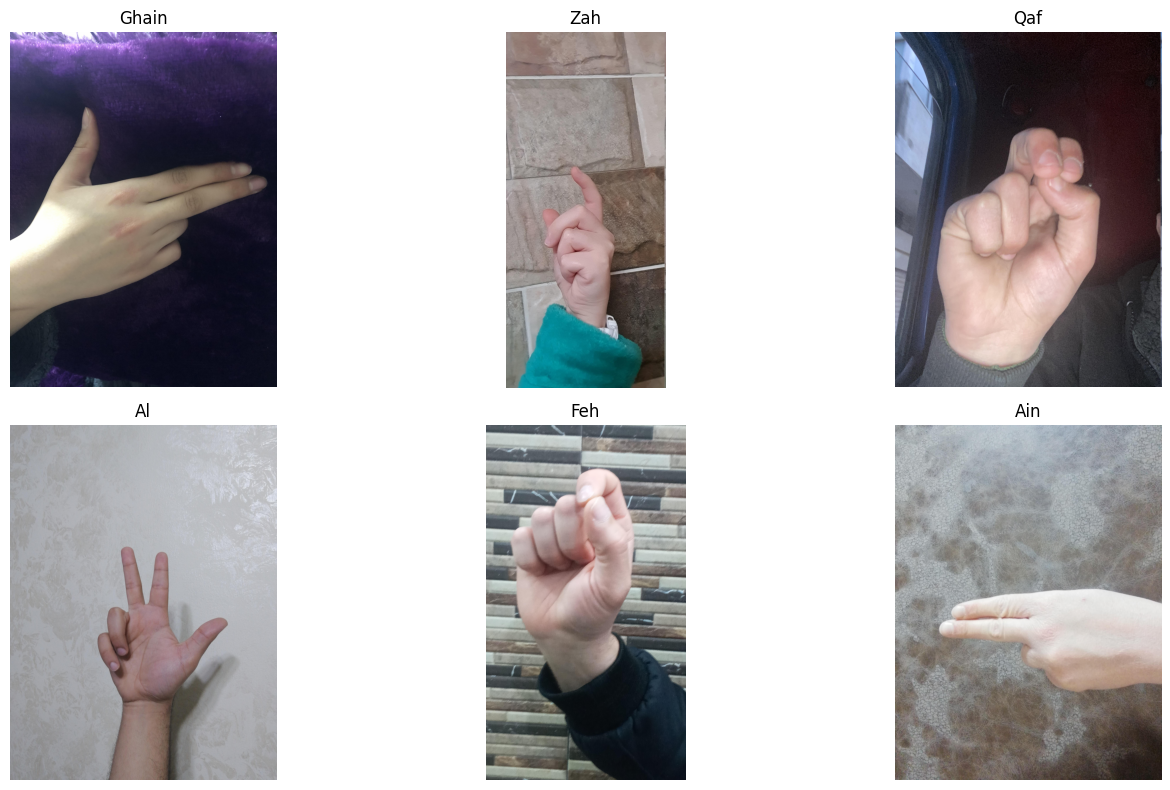

In [90]:
import random
import cv2

selected_classes = random.sample(list(class_counts.keys()), 6)

plt.figure(figsize=(15, 8))

for i, class_name in enumerate(selected_classes):
    class_path = os.path.join(data_dir, class_name)

    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [91]:
print("Image shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum pixel value:", image.min())
print("Maximum pixel value:", image.max())

Image shape: (3264, 2448, 3)
Data type: uint8
Minimum pixel value: 4
Maximum pixel value: 255


In [92]:
#checking resolution of different image samples
for i in range(10):
    class_name = random.choice(list(class_counts.keys()))
    class_path = os.path.join(data_dir, class_name)

    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    img = cv2.imread(image_path)

    print(class_name, "->", img.shape)

Seen -> (4000, 3000, 3)
Teh_Marbuta -> (2000, 1500, 3)
Ghain -> (4128, 3096, 3)
Thal -> (4000, 3000, 3)
Jeem -> (2592, 1944, 3)
Yeh -> (4032, 3024, 3)
Reh -> (3088, 2320, 3)
Waw -> (4160, 3120, 3)
Dad -> (1280, 960, 3)
Thal -> (608, 630, 3)


we will use 224 * 224 * 3 image resolution , so we need to resize all images to this size

In [93]:
#testing padding to avoid squashing the hand pictures

resized_image = tf.image.resize_with_pad(
    image,
    target_height=224,
    target_width=224
)

print("Original shape:", image.shape)
print("New shape:", resized_image.shape)

Original shape: (3264, 2448, 3)
New shape: (224, 224, 3)


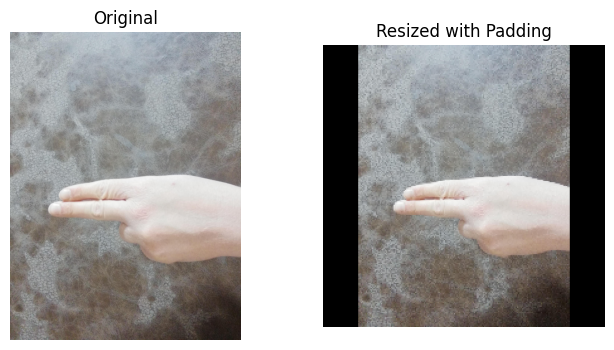

In [94]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tf.cast(resized_image, tf.uint8))
plt.title("Resized with Padding")
plt.axis("off")

plt.show()

the shape of the fingers and hand is extremely important for sign classification

In [95]:
classes_to_check = ["Alef", "Beh", "Teh"]

for class_name in classes_to_check:
    class_path = os.path.join(data_dir, class_name)

    print(f"\n{class_name}:")
    print(os.listdir(class_path)[:10])


Alef:
['Alef_161.jpg', 'Alef_282.jpg', 'Alef_219.jpg', 'Alef_256.jpg', 'Alef_107.jpg', 'Alef_213.jpg', 'Alef_97.jpg', 'Alef_80.jpeg', 'Alef_278.jpeg', 'Alef_16.jpg']

Beh:
['Beh_175.jpg', 'Beh_289.jpg', 'Beh_70.jpg', 'Beh_292.jpeg', 'Beh_47.jpg', 'Beh_35.jpg', 'Beh_199.jpg', 'Beh_103.jpeg', 'Beh_34.jpeg', 'Beh_96.jpg']

Teh:
['Teh_217.jpg', 'Teh_39.jpg', 'Teh_268.jpg', 'Teh_142.jpg', 'Teh_91.jpg', 'Teh_154.jpeg', 'Teh_96.jpeg', 'Teh_293.jpg', 'Teh_102.jpg', 'Teh_251.jpg']


we will use stratified split 70% training
                     15% validation
                     15% testing , since stratification tries to preserve the class proportions

In [96]:
import pandas as pd

filepaths = []
labels = []

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):

        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            filepaths.append(image_path)
            labels.append(class_name)

data = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

data.head()

,filepath,label
0,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
1,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
2,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
3,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
4,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain


In [97]:
print("Total images:", len(data))
print("Number of classes:", data["label"].nunique())

data.head()

Total images: 7856
Number of classes: 31


,filepath,label
0,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
1,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
2,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
3,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
4,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain


In [98]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(
    data,
    test_size=0.30,
    random_state=42,
    stratify=data["label"]
)

In [99]:
val_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    random_state=42,
    stratify=temp_data["label"]
)

In [100]:
print("Training images:", len(train_data))
print("Validation images:", len(val_data))
print("Testing images:", len(test_data))

Training images: 5499
Validation images: 1178
Testing images: 1179


In [101]:
#making sure splits are stratified
print("TRAIN")
print(train_data["label"].value_counts(normalize=True).head())

print("\nVALIDATION")
print(val_data["label"].value_counts(normalize=True).head())

print("\nTEST")
print(test_data["label"].value_counts(normalize=True).head())

TRAIN
label
Teh      0.039644
Beh      0.039098
Theh     0.038734
Alef     0.036552
Sheen    0.035461
Name: proportion, dtype: float64

VALIDATION
label
Theh    0.039049
Beh     0.039049
Teh     0.039049
Alef    0.036503
Al      0.034805
Name: proportion, dtype: float64

TEST
label
Teh     0.039864
Theh    0.039016
Beh     0.039016
Alef    0.036472
Al      0.035623
Name: proportion, dtype: float64


In [102]:
class_names = sorted(data["label"].unique())

print(class_names)
print("Number of classes:", len(class_names))

['Ain', 'Al', 'Alef', 'Beh', 'Dad', 'Dal', 'Feh', 'Ghain', 'Hah', 'Heh', 'Jeem', 'Kaf', 'Khah', 'Laa', 'Lam', 'Meem', 'Noon', 'Qaf', 'Reh', 'Sad', 'Seen', 'Sheen', 'Tah', 'Teh', 'Teh_Marbuta', 'Thal', 'Theh', 'Waw', 'Yeh', 'Zah', 'Zain']
Number of classes: 31


In [103]:
#label encoding
label_to_index = {
    label: index
    for index, label in enumerate(class_names)
}

print(label_to_index)

{'Ain': 0, 'Al': 1, 'Alef': 2, 'Beh': 3, 'Dad': 4, 'Dal': 5, 'Feh': 6, 'Ghain': 7, 'Hah': 8, 'Heh': 9, 'Jeem': 10, 'Kaf': 11, 'Khah': 12, 'Laa': 13, 'Lam': 14, 'Meem': 15, 'Noon': 16, 'Qaf': 17, 'Reh': 18, 'Sad': 19, 'Seen': 20, 'Sheen': 21, 'Tah': 22, 'Teh': 23, 'Teh_Marbuta': 24, 'Thal': 25, 'Theh': 26, 'Waw': 27, 'Yeh': 28, 'Zah': 29, 'Zain': 30}


In [104]:
train_data = train_data.copy()
val_data = val_data.copy()
test_data = test_data.copy()

train_data["label_id"] = train_data["label"].map(label_to_index)
val_data["label_id"] = val_data["label"].map(label_to_index)
test_data["label_id"] = test_data["label"].map(label_to_index)

In [105]:
#processing one image
IMG_SIZE = 224

def load_and_preprocess_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize_with_pad(
        image,
        IMG_SIZE,
        IMG_SIZE
    )

    image = tf.cast(image, tf.float32)

    return image, label

In [106]:
def create_dataset(dataframe, shuffle=False):

    filepaths = dataframe["filepath"].values
    labels = dataframe["label_id"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(32)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [107]:
train_ds = create_dataset(train_data, shuffle=True)

val_ds = create_dataset(val_data)

test_ds = create_dataset(test_data)

In [108]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

    print("\nFirst 10 labels:")
    print(labels[:10].numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)

First 10 labels:
[24  2 17 22  3 21  9 28 27 10]


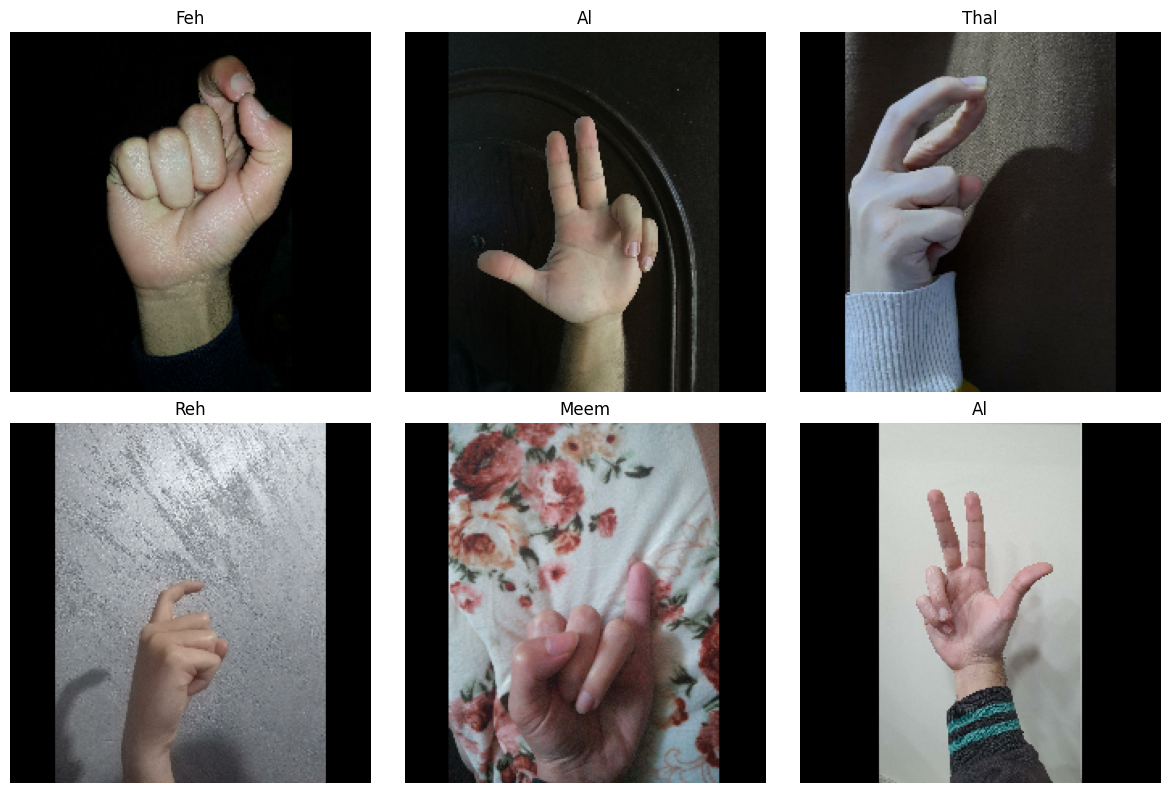

In [109]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    for i in range(6):

        plt.subplot(2, 3, i + 1)

        plt.imshow(
            tf.cast(images[i], tf.uint8)
        )

        label_number = labels[i].numpy()

        plt.title(
            class_names[label_number]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [110]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
])

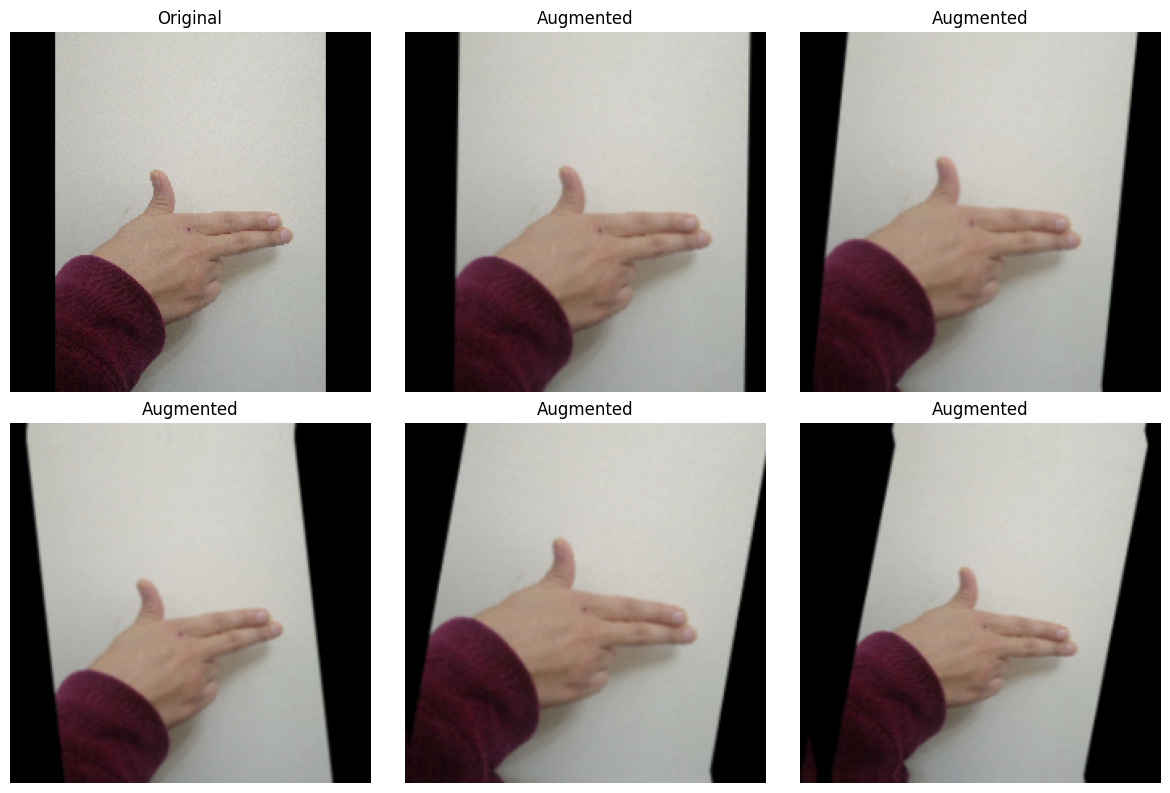

In [111]:
for images, labels in train_ds.take(1):

    original = images[0]

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(tf.cast(original, tf.uint8))
    plt.title("Original")
    plt.axis("off")

    for i in range(5):
        augmented = data_augmentation(
            tf.expand_dims(original, 0),
            training=True
        )

        plt.subplot(2, 3, i + 2)
        plt.imshow(
            tf.cast(augmented[0], tf.uint8)
        )
        plt.title("Augmented")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [112]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [113]:
base_model.trainable = True

# Freeze the first layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [114]:
from tensorflow.keras import layers, models

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

In [115]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 31)             │        39,711 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,297,695 (8.77 MB)

 Trainable params: 1,566,111 (5.97 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [116]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [120]:
fine_tune_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[fine_tune_early_stopping]
)

Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8161 - loss: 0.6329 - val_accuracy: 0.8098 - val_loss: 0.6440
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.8289 - loss: 0.5898 - val_accuracy: 0.8200 - val_loss: 0.6250
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.8411 - loss: 0.5605 - val_accuracy: 0.8328 - val_loss: 0.6021
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.8436 - loss: 0.5461 - val_accuracy: 0.8345 - val_loss: 0.5842
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.8478 - loss: 0.5021 - val_accuracy: 0.8370 - val_loss: 0.5698
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.8716 - loss: 0.4660 - val_accuracy: 0.8396 - val_loss: 0.5513
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.8645 - loss: 0.4571 - val_accuracy: 0.8404 - val_loss: 0.5403
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.8774 - loss: 0.4295 - val_accu

In [121]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

37/37 ━━━━━━━━━━━━━━━━━━━━ 32s 857ms/step - accuracy: 0.8601 - loss: 0.4237
Test Loss: 0.42365777492523193
Test Accuracy: 0.8600509166717529
